# Resource Selection Function

In [22]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np
import ee

from movement_models import (
    FeatureSpec,
    _build_design_matrix,
    _get_availability_domain,
    _get_sampling_points,
    _sample_env_layer,
    load_presence_csvs,
    to_reloc_gdf,
    reproject_reloc,
    to_reloc_gdf_projected,
    init_ee,
    init_ee_on_client,
    make_aoi,
    aoi_to_ee,
    build_predictors_image,
    ee_image_to_env_xarray,
    save_env_zarr,
    load_env_zarr,
    shutdown_default_client,
    make_local_dask_client,
    
    fit_rsf,
    predict_rsf_points,
    get_rsf_surface,
    fixed_width_Boyce,
    sliding_window_Boyce,
    cv_model,
    eval_all_linear_candidates
)

In [11]:
def _choose_chunk_size_points(env, *, client=None, frac_of_worker_mem=0.10, per_worker_budget_mb=None, k=10,
    min_points=1_000, max_points=200_000):

    if client is not None:
        info = client.scheduler_info()["workers"]
        limits_mb = [w["memory_limit"] / 1024**2 for w in info.values()]
        base_budget_mb = min(limits_mb) * frac_of_worker_mem
        per_worker_budget_mb = int(max(8, min(512, base_budget_mb)))
    else:
        if per_worker_budget_mb is None:
            per_worker_budget_mb = 16  # conservative fallback
        per_worker_budget_mb = int(per_worker_budget_mb)

    if hasattr(env, "dims") and "band" in env.dims:
        n_bands = int(env.sizes["band"])
        dtype = env.dtype
    else:
        n_bands = len(env.data_vars)
        dtype = next(iter(env.data_vars.values())).dtype

    bytes_per_value = np.dtype(dtype).itemsize
    budget_bytes = per_worker_budget_mb * 1024 * 1024

    bytes_per_point = n_bands * bytes_per_value
    n_points = budget_bytes // (k * bytes_per_point)

    return int(min(max_points, max(min_points, n_points)))

In [12]:
def _sample_env_layer_old(
    samples: gpd.GeoDataFrame,
    env: xr.DataArray,
    chunk_size_points="auto",
    *,
    client=None,
    per_worker_budget_mb=16,
    k=10,
    min_points=1_000,
    max_points=200_000,
):
    try:
        env_crs = env.rio.crs
    except Exception:
        env_crs = None

    if env_crs is None:
        raise ValueError("env has no rio CRS; set it with env = env.rio.write_crs('EPSG:...')")

    if samples.crs is None:
        raise ValueError("samples.crs is None; set a CRS on your GeoDataFrame before sampling")

    if samples.crs != env_crs:
        samples = samples.to_crs(env_crs)

    if chunk_size_points == "auto" or chunk_size_points is None:
        chunk_size_points = _choose_chunk_size_points(
            env,
            client=client,
            per_worker_budget_mb=per_worker_budget_mb,
            k=k,
            min_points=min_points,
            max_points=max_points,
        )
    else:
        chunk_size_points = int(chunk_size_points)

    xs = xr.DataArray(samples.geometry.x.to_numpy(), dims="points", name="x")
    ys = xr.DataArray(samples.geometry.y.to_numpy(), dims="points", name="y")

    sampled = env.sel(x=xs, y=ys, method="nearest").chunk({"points": chunk_size_points})

    arr = sampled.data
    arr = arr.compute() if hasattr(arr, "compute") else np.asarray(arr)
    arr = np.asarray(arr, dtype="float32")

    bands = sampled["band"].to_numpy().tolist()
    df = pd.DataFrame(arr.T, columns=bands)
    df["x"] = xs.to_numpy()
    df["y"] = ys.to_numpy()
    df["used"] = samples["used"].to_numpy()
    df["Timestamp"] = samples["Timestamp"].to_numpy()
    return df

In [13]:
import importlib
import movement_models.sampling as smp
importlib.reload(smp)

_sample_env_layer_new = smp._sample_env_layer

In [14]:
subset_predictors = ["ndvi", "ndwi"]
cov = env.sel(band=subset_predictors)

domain = _get_availability_domain(reloc)
samples = _get_sampling_points(domain, 10_000, df=reloc.iloc[:1000], seed=1)

/Users/lubovkabo/Documents/TUM/MolZoologyLab/KONWIHR/HSA/movement_models/sampling.py:45: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  samples["used"] = samples["used"].fillna(False)


In [15]:
from time import perf_counter

t0 = perf_counter()
out_old = _sample_env_layer_old(samples, cov, chunk_size_points="auto", client=client)
t1 = perf_counter()

t2 = perf_counter()
out_new = _sample_env_layer(samples, cov, chunk_size_points="auto", client=client)
t3 = perf_counter()

print("old runtime:", t1 - t0)
print("new runtime:", t3 - t2)

NameError: name 'client' is not defined

In [ ]:
print(out_old.shape, out_new.shape)
print(list(out_old.columns))
print(list(out_new.columns))

In [ ]:
import numpy as np

sort_cols = ["Timestamp", "used", "x", "y"]

a = out_old.sort_values(sort_cols).reset_index(drop=True)
b = out_new.sort_values(sort_cols).reset_index(drop=True)

print((a["used"].values == b["used"].values).all())
print((a["Timestamp"].values == b["Timestamp"].values).all())

float_cols = ["x", "y"] + subset_predictors

for col in float_cols:
    ok = np.allclose(a[col].to_numpy(), b[col].to_numpy(), equal_nan=True, rtol=1e-7, atol=1e-8)
    max_diff = np.nanmax(np.abs(a[col].to_numpy() - b[col].to_numpy()))
    print(col, ok, max_diff)

In [ ]:
spec = FeatureSpec(linear=subset_predictors, add_const=True)

m_old, scaler_old, _ = fit_rsf(out_old, spec)
pred_old = predict_rsf_points(out_old, m_old, scaler_old, spec)
rsf_old = get_rsf_surface(cov, m_old, scaler_old, spec, crs=cov.rio.crs)
B_old, _ = fixed_width_Boyce(pred_old, rsf_old, domain, seed=1)

m_new, scaler_new, _ = fit_rsf(out_new, spec)
pred_new = predict_rsf_points(out_new, m_new, scaler_new, spec)
rsf_new = get_rsf_surface(cov, m_new, scaler_new, spec, crs=cov.rio.crs)
B_new, _ = fixed_width_Boyce(pred_new, rsf_new, domain, seed=1)

print("Boyce old:", B_old)
print("Boyce new:", B_new)

In [16]:
client = make_local_dask_client(memory_limit="2GB") 

init_status = init_ee_on_client(client, project_id="ee-alvykabo")
client, init_status

(<Client: 'tcp://127.0.0.1:49427' processes=5 threads=5, memory=9.31 GiB>,
 {'tcp://127.0.0.1:49450': 1,
  'tcp://127.0.0.1:49451': 1,
  'tcp://127.0.0.1:49452': 1,
  'tcp://127.0.0.1:49453': 1,
  'tcp://127.0.0.1:49454': 1})

2026-04-03 20:42:07,925 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:49454' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'shuffle-taker-6f6c95fb310be70815e18c020fc50641'} (stimulus_id='handle-worker-cleanup-1775241727.9252841')
2026-04-04 10:26:10,789 - tornado.application - ERROR - Exception in callback <bound method SystemMonitor.update of <SystemMonitor: cpu: 1 memory: 639 MB fds: 188>>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/cleanjupyter/lib/python3.12/site-packages/tornado/ioloop.py", line 945, in _run
    val = self.callback()
          ^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/cleanjupyter/lib/python3.12/site-packages/distributed/system_monitor.py", line 168, in update
    net_ioc = psutil.net_io_counters()
              ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/cleanjupyter/lib/python3.12/site-packages/psutil/__init__.py", line 2148, in net_io_counters
    rawdict = _psplatf

## speed testing

In [21]:
import time
import pandas as pd

results = []

point_counts = [10_000, 25_000, 50_000, 100_000]

for n in point_counts:
    pts = _get_sampling_points(domain, n, seed=1)

    # 1) fixed small / high-overhead baseline
    t0 = time.perf_counter()
    _ = _sample_env_layer(
        pts,
        env.sel(band=["ndvi", "slope"]),
        chunk_size_points=1_000,
        client=None,
    )
    t1 = time.perf_counter()
    results.append({"n_points": n, "method": "sequential_like", "runtime_sec": t1 - t0})

    # 2) old fixed chunking
    t0 = time.perf_counter()
    _ = _sample_env_layer(
        pts,
        env.sel(band=["ndvi", "slope"]),
        chunk_size_points=20_000,
        client=client,
    )
    t1 = time.perf_counter()
    results.append({"n_points": n, "method": "fixed_dask", "runtime_sec": t1 - t0})

    # 3) new adaptive chunking
    t0 = time.perf_counter()
    _ = _sample_env_layer(
        pts,
        env.sel(band=["ndvi", "slope"]),
        chunk_size_points="auto",
        client=client,
    )
    t1 = time.perf_counter()
    results.append({"n_points": n, "method": "auto_chunk", "runtime_sec": t1 - t0})

bench = pd.DataFrame(results)
bench

Task exception was never retrieved
future: <Task finished name='Task-3481303' coro=<Client._gather.<locals>.wait() done, defined at /opt/anaconda3/envs/cleanjupyter/lib/python3.12/site-packages/distributed/client.py:2399> exception=AllExit()>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/cleanjupyter/lib/python3.12/site-packages/distributed/client.py", line 2408, in wait
    raise AllExit()
distributed.client.AllExit


KeyboardInterrupt: 

## 1. Preparation

### 1.1 Fetch presence data

In [5]:
reloc_df = load_presence_csvs("data/*.csv")
reloc = to_reloc_gdf(reloc_df)

reloc.head(), reloc.crs, reloc["Timestamp"].dtype

(            Timestamp     ID  Latitude  Longitude                    geometry
 0 2024-05-04 14:31:32  NPL38 -19.50359   14.21912  POINT (14.21912 -19.50359)
 1 2024-05-04 14:32:42  NPL38 -19.50360   14.21912   POINT (14.21912 -19.5036)
 2 2024-05-04 20:37:42  NPL38 -19.51765   14.21877  POINT (14.21877 -19.51765)
 3 2024-05-04 20:38:09  NPL38 -19.51763   14.21878  POINT (14.21878 -19.51763)
 4 2024-05-04 22:43:10  NPL38 -19.47570   14.22619   POINT (14.22619 -19.4757),
 <Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich,
 dtype('<M8[ns]'))

### 1.2 Fetch environmental layers

In [6]:
ee.Authenticate()
init_ee(project_id="ee-alvykabo")   

aoi = make_aoi(reloc, buffer_m=1)
aoi_ee = aoi_to_ee(aoi)

predictors_img = build_predictors_image(aoi_ee, start="2024-01-01", end="2024-12-31")
env = ee_image_to_env_xarray(predictors_img, aoi_ee, crs="EPSG:29333", scale=100, chunk_xy=1024)

save_env_zarr(env, "env_29333.zarr", mode="w")
env2 = load_env_zarr("env_29333.zarr")

env.shape, env.rio.crs, env2.shape

Enter verification code:  4/1Aci98E_oMFodYVUQRIG24jAC1x1hMrXQQOEm4v1Imlkn3501cvM5w0AhtwU



Successfully saved authorization token.


/opt/anaconda3/envs/cleanjupyter/lib/python3.12/site-packages/xee/ext.py:696: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(
/opt/anaconda3/envs/cleanjupyter/lib/python3.12/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


((4, 2663, 2310),
 CRS.from_wkt('PROJCS["Schwarzeck / UTM zone 33S",GEOGCS["Schwarzeck",DATUM["Schwarzeck",SPHEROID["Bessel Namibia (GLM)",6377483.86528042,299.1528128,AUTHORITY["EPSG","7046"]],AUTHORITY["EPSG","6293"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4293"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","29333"]]'),
 (4, 2663, 2310))

## 2. Calculate the RSF

### 2.1 Define the sampling scheme

In [ ]:
domain = _get_availability_domain(reloc)
samples = _get_sampling_points(domain, 1000, df=reloc.iloc[:100], seed=1)
sampled = _sample_env_layer(samples, env.sel(band=["ndvi", "slope"]), chunk_size_points="auto", client=None)

sampled.head()

/Users/lubovkabo/Documents/TUM/MolZoologyLab/KONWIHR/HSA/movement_models/sampling.py:45: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  samples["used"] = samples["used"].fillna(False)


### 2.2 Extract values from the environmental covariates

### 2.3 Fit logistic regression

In [ ]:
spec = FeatureSpec(linear=["ndvi", "slope"], add_const=True)
m, scaler, _ = fit_rsf(sampled, spec)
pred = predict_rsf_points(sampled, m, scaler, spec)

pred[["rsf_pred"]].describe()

### 2.4 Get RSF surface

In [ ]:
rsf = get_rsf_surface(env.sel(band=spec.linear), m, scaler, spec)

rsf

In [ ]:
rsf = get_rsf_surface(env, m, scaler, spec)
rsf = rsf.compute()
rsf.rio.to_raster("rsf.tif", compress="LZW")
rsf = rsf.rio.write_crs("EPSG:29333") 

In [ ]:
client.scheduler_info()["workers"].keys()
len(client.scheduler_info()["workers"])

In [ ]:
import pandas as pd

info = client.scheduler_info()["workers"]

df = pd.DataFrame({
    w: {
        "memory": data["metrics"]["memory"],
        "memory_limit": data["memory_limit"]
    }
    for w, data in info.items()
}).T

df

In [ ]:
df["memory_MB"] = df["memory"] / 1e6
df["limit_MB"] = df["memory_limit"] / 1e6
df[["memory_MB", "limit_MB"]]

### 2.5 Evaluate Using Boyce Index

In [ ]:
subset_predictors = ["ndvi", "ndwi", "slope", "dist2water"]
cov = env.sel(band=subset_predictors)

samples = _get_sampling_points(domain, n=10_000, df=reloc.iloc[:1000], seed=1)
sampled = _sample_env_layer(samples, cov, chunk_size_points="auto", client=client)

spec = FeatureSpec(linear=subset_predictors, add_const=True)
m, scaler, spec = fit_rsf(sampled, spec)

pred = predict_rsf_points(sampled, m, scaler, spec)
rsf = get_rsf_surface(env.sel(band=subset_predictors), m, scaler, spec)

B, boyce = fixed_width_Boyce(pred, rsf, domain, seed=1)
B, boyce.head()

In [ ]:
B, chart = sliding_window_Boyce(
    pred=pred,
    rsf=rsf,
    domain=domain,
    window_frac=0.2,
    step_frac=0.05,
    seed=1,
)

print("B =", B)
print(chart.head())
print("rows:", len(chart), "finite pe:", chart["pe"].notna().sum())

## 3. Aggregate functions

### 3.1 Compare all possible linear models via AIC & BIC

In [ ]:
df_small = sampled.sample(n=min(2000, len(sampled)), random_state=1).copy()
subset_predictors = ["ndvi", "ndwi", "slope", "dist2water"]

df_small = df_small.replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["used"] + subset_predictors)

res = eval_all_linear_candidates(df_small, env, subset=subset_predictors)
res.head()

### 3.2 Cross-Validation on a Single Individual

In [ ]:
res = cv_model(
    obs=reloc,
    env=env,
    k_folds=2,
    subset_predictors=["ndvi", "ndwi", "slope", "dist2water"],
    sampling_factor_train=3,
    n_bg_boyce=5_000,
    seed=1,
)
res

# Step, Length, & Turning Angle

In [1]:
#testing movement_kernel.py with likelihood-based fitting

from movement_models.movement import (
    prepare_trajectory_data,
    build_step_data,
    fit_step_distribution,
    build_turn_angle_data,
    fit_turn_angle_distribution,
    fit_movement_kernel_per_id,
)

from movement_models.io import (
    load_presence_csvs,
    to_reloc_gdf_projected,
)

from movement_models.io import load_presence_csvs
from movement_models.movement import fit_movement_kernel_per_id

reloc = load_presence_csvs("data/*.csv")

out = fit_movement_kernel_per_id(
    reloc,
    id_col="ID",
    timestamp_col="Timestamp",
    lon_col="Longitude",
    lat_col="Latitude",
    target_crs="EPSG:29333",
    expected_interval_min=120,
    tolerance_min=2,
    step_cutoff=20000,
)

out["summary"]

,ID,n_steps,step_distribution,step_params,step_q25,step_median,step_mean,step_q75,step_max,n_angles,vonmises_kappa,mixture_kappa,mixture_w
0,NPL38,2584,lognorm,"[2.3680072661020657, 76.329595410113]",8.809685,63.692252,546.335874,760.120739,7014.598776,2252,0.135231,6.79407,0.103583


In [38]:
step_df = out["step_df"]
one_id = step_df["ID"].dropna().iloc[0]
step_subset = step_df.loc[step_df["ID"] == one_id, "step_m"]

fit_step_distribution(step_subset)["model_table"]

,distribution,params,loglik,AIC,success
0,lognorm,"[2.3680072661020657, 76.329595410113]",-17095.920956,34195.841913,True
1,weibull,"[0.4683982286268443, 249.18223047700394]",-17177.628049,34359.256097,True
2,gamma,"[0.3428314692397524, 1593.5262762864115]",-17250.213319,34504.426638,True
3,exp,[546.3358741887124],-18871.556503,37745.113006,True


# testing Bayesian MCMC on the exp model

In [71]:
import importlib
import movement_models.movement.movement_kernel as mk
importlib.reload(mk)

<module 'movement_models.movement.movement_kernel' from '/Users/lubovkabo/Documents/TUM/MolZoologyLab/KONWIHR/HSA/movement_models/movement/movement_kernel.py'>

In [61]:
res = fit_exp_distribution_bayes(step_subset)
res

{'samples': array([546.33587419, 546.6009308 , 546.6009308 , ..., 538.0580381 ,
        536.79015887, 536.79015887]),
 'posterior_samples': array([538.60458415, 538.60458415, 541.53735174, ..., 538.0580381 ,
        536.79015887, 536.79015887]),
 'acceptance_rate': 0.29415,
 'posterior_mean': 546.5790895870294,
 'posterior_median': 546.3920726355088,
 'posterior_q025': 526.066319262461,
 'posterior_q975': 569.5310356534479,
 'init_scale': 546.3358741887124,
 'proposal_sd': 0.08,
 'prior_sigma': 5000.0,
 'n': 2584}

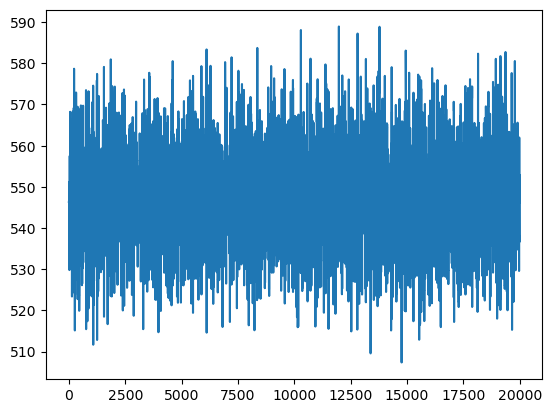

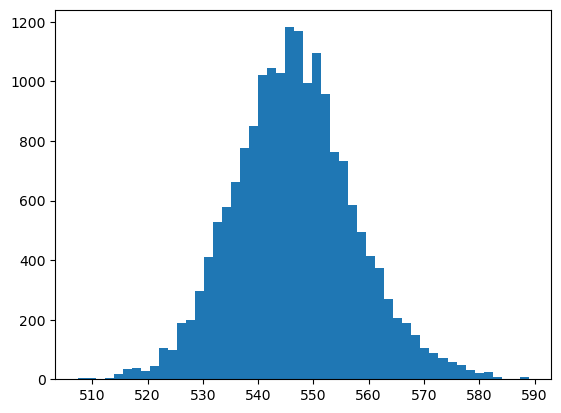

In [62]:
import matplotlib.pyplot as plt

plt.plot(res["samples"])
plt.show()

plt.hist(res["posterior_samples"], bins=50)
plt.show()

# testing Bayesian MCMC on the gamma model

In [64]:
res_gamma = fit_gamma_distribution_bayes(
    step_subset,
    proposal_sd_shape=0.05,
    proposal_sd_scale=0.05,
)

res_gamma

{'n': 2584,
 'q25': 8.809684671890794,
 'median': 63.69225183945225,
 'mean': 546.3358741887124,
 'q75': 760.120739014744,
 'max': 7014.59877565373,
 'distribution': 'gamma_bayes',
 'posterior_mean_shape': 0.3428503946336651,
 'posterior_median_shape': 0.34266632261228414,
 'posterior_q025_shape': 0.3281837385133352,
 'posterior_q975_shape': 0.3586348887335786,
 'posterior_mean_scale': 1596.113471363443,
 'posterior_median_scale': 1594.3531538083855,
 'posterior_q025_scale': 1481.1135163117335,
 'posterior_q975_scale': 1727.6776387454777,
 'acceptance_rate': 0.2975,
 'init_shape': 1.0,
 'init_scale': 546.3358741887124,
 'proposal_sd_shape': 0.05,
 'proposal_sd_scale': 0.05,
 'shape_prior': 2.0,
 'scale_prior': 5000.0,
 'samples': array([[1.00000000e+00, 5.46335874e+02],
        [1.00000000e+00, 5.46335874e+02],
        [9.94097061e-01, 5.44844068e+02],
        ...,
        [3.36274155e-01, 1.59862245e+03],
        [3.36274155e-01, 1.59862245e+03],
        [3.36274155e-01, 1.59862245e+0

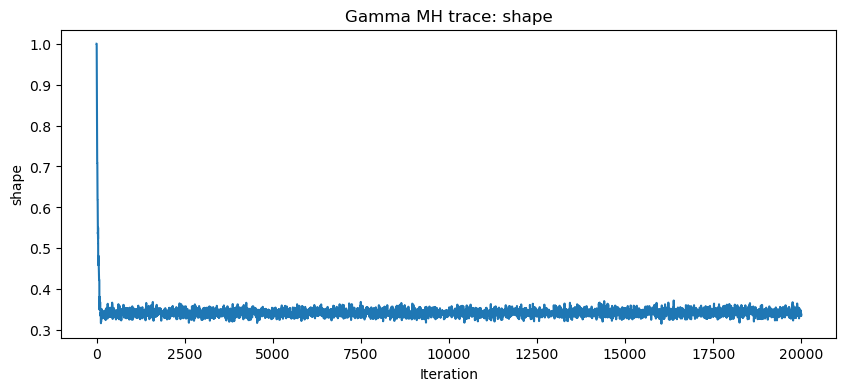

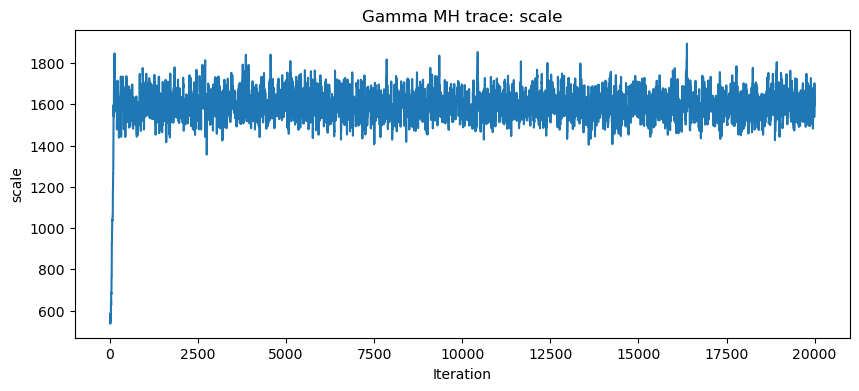

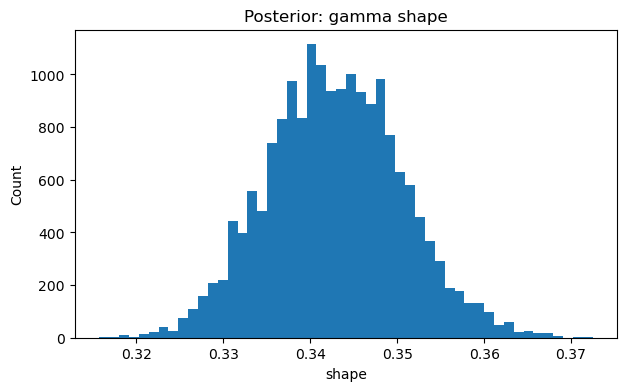

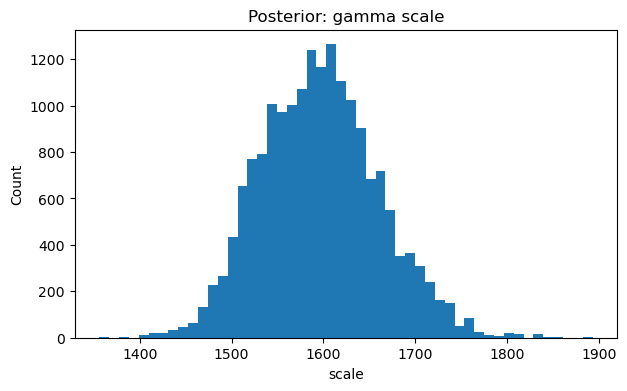

In [65]:
import matplotlib.pyplot as plt

shape_chain = res_gamma["samples"][:, 0]
scale_chain = res_gamma["samples"][:, 1]

plt.figure(figsize=(10, 4))
plt.plot(shape_chain)
plt.xlabel("Iteration")
plt.ylabel("shape")
plt.title("Gamma MH trace: shape")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(scale_chain)
plt.xlabel("Iteration")
plt.ylabel("scale")
plt.title("Gamma MH trace: scale")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(res_gamma["posterior_samples"][:, 0], bins=50)
plt.xlabel("shape")
plt.ylabel("Count")
plt.title("Posterior: gamma shape")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(res_gamma["posterior_samples"][:, 1], bins=50)
plt.xlabel("scale")
plt.ylabel("Count")
plt.title("Posterior: gamma scale")
plt.show()

# testing Bayesian MCMC on the weibull model

In [68]:
res_weibull = fit_weibull_distribution_bayes(
    step_subset,
    proposal_sd_shape=0.05,
    proposal_sd_scale=0.05,
)

res_weibull

{'n': 2584,
 'q25': 8.809684671890794,
 'median': 63.69225183945225,
 'mean': 546.3358741887124,
 'q75': 760.120739014744,
 'max': 7014.59877565373,
 'distribution': 'weibull_bayes',
 'posterior_mean_shape': 0.46844197812168176,
 'posterior_median_shape': 0.4684239920822979,
 'posterior_q025_shape': 0.4542181419303111,
 'posterior_q975_shape': 0.482754337532848,
 'posterior_mean_scale': 249.28944022988736,
 'posterior_median_scale': 248.98818094752198,
 'posterior_q025_scale': 228.23462870861306,
 'posterior_q975_scale': 272.18331157788936,
 'acceptance_rate': 0.26275,
 'init_shape': 1.0,
 'init_scale': 546.3358741887124,
 'proposal_sd_shape': 0.05,
 'proposal_sd_scale': 0.05,
 'shape_prior': 2.0,
 'scale_prior': 5000.0,
 'samples': array([[1.00000000e+00, 5.46335874e+02],
        [1.00000000e+00, 5.46335874e+02],
        [1.00000000e+00, 5.46335874e+02],
        ...,
        [4.69861259e-01, 2.57243756e+02],
        [4.69861259e-01, 2.57243756e+02],
        [4.69861259e-01, 2.57243756

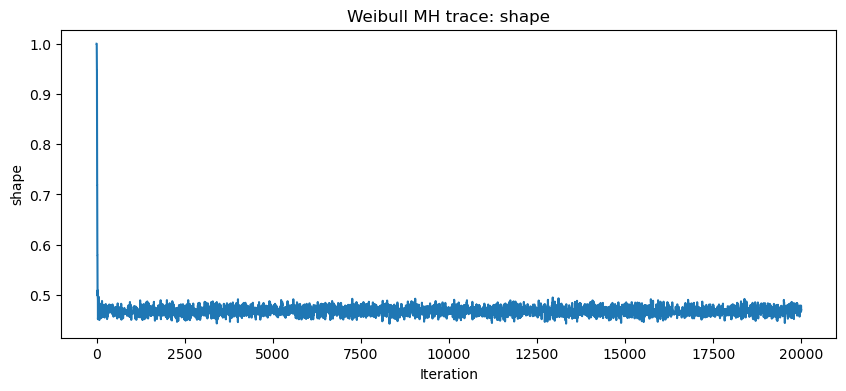

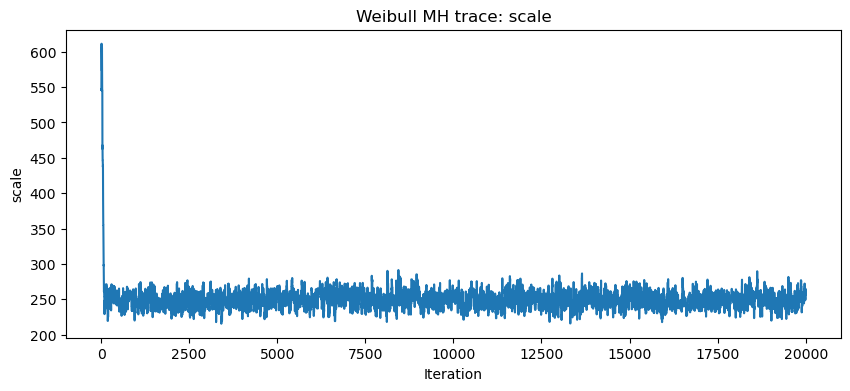

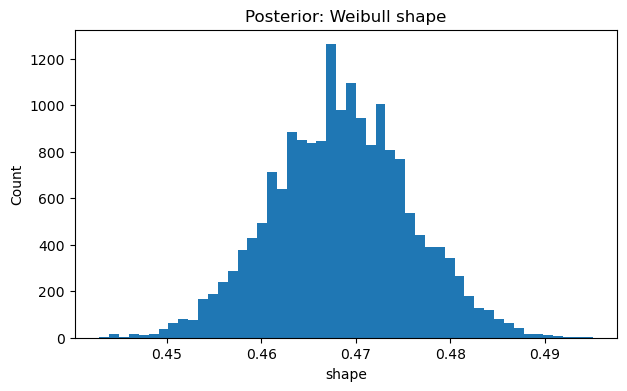

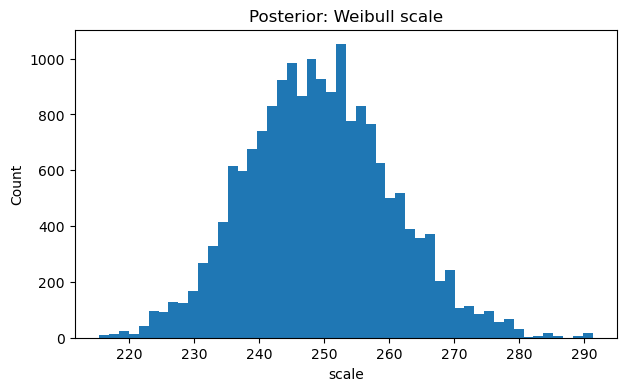

In [69]:
import matplotlib.pyplot as plt

shape_chain = res_weibull["samples"][:, 0]
scale_chain = res_weibull["samples"][:, 1]

plt.figure(figsize=(10, 4))
plt.plot(shape_chain)
plt.xlabel("Iteration")
plt.ylabel("shape")
plt.title("Weibull MH trace: shape")
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(scale_chain)
plt.xlabel("Iteration")
plt.ylabel("scale")
plt.title("Weibull MH trace: scale")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(res_weibull["posterior_samples"][:, 0], bins=50)
plt.xlabel("shape")
plt.ylabel("Count")
plt.title("Posterior: Weibull shape")
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(res_weibull["posterior_samples"][:, 1], bins=50)
plt.xlabel("scale")
plt.ylabel("Count")
plt.title("Posterior: Weibull scale")
plt.show()

# testing Bayesian MCMC on the lognormal model

In [75]:
res_lognorm = fit_lognorm_distribution_bayes(
    step_subset,
    proposal_sd_mu=0.05,
    proposal_sd_sigma=0.05,
)

res_lognorm

{'n': 2584,
 'q25': 8.809684671890794,
 'median': 63.69225183945225,
 'mean': 546.3358741887124,
 'q75': 760.120739014744,
 'max': 7014.59877565373,
 'distribution': 'lognorm_bayes',
 'posterior_mean_mu': 4.334682792416876,
 'posterior_median_mu': 4.3343642840672665,
 'posterior_q025_mu': 4.243099522767029,
 'posterior_q975_mu': 4.423986183770285,
 'posterior_mean_sigma': 2.3703816387722756,
 'posterior_median_sigma': 2.370165386032752,
 'posterior_q025_sigma': 2.30742651832065,
 'posterior_q975_sigma': 2.4376102887046054,
 'acceptance_rate': 0.24415,
 'init_mu': 4.335074000879982,
 'init_sigma': 1.0,
 'proposal_sd_mu': 0.05,
 'proposal_sd_sigma': 0.05,
 'mu_prior': 0.0,
 'sigma_prior': 10.0,
 'samples': array([[4.31482237, 1.00828356],
        [4.31482237, 1.00828356],
        [4.31482237, 1.00828356],
        ...,
        [4.31101628, 2.35773204],
        [4.31101628, 2.35773204],
        [4.31101628, 2.35773204]]),
 'posterior_samples': array([[4.40201571, 2.35256955],
        [4.40

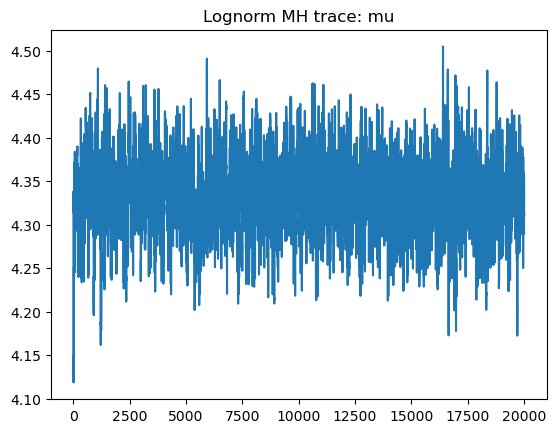

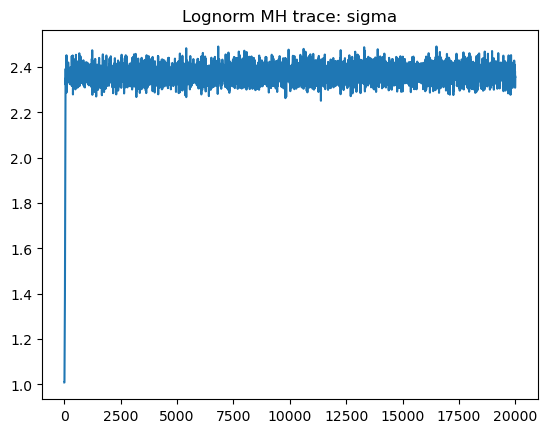

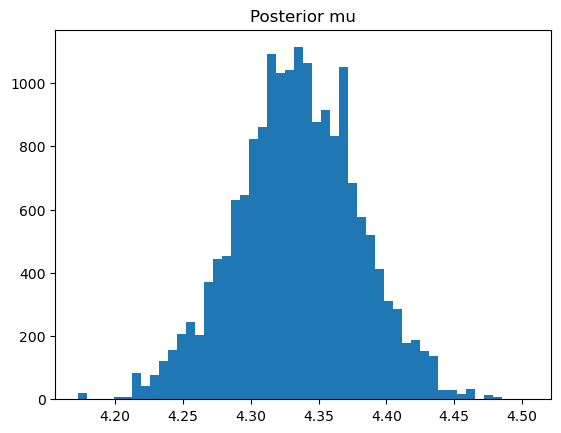

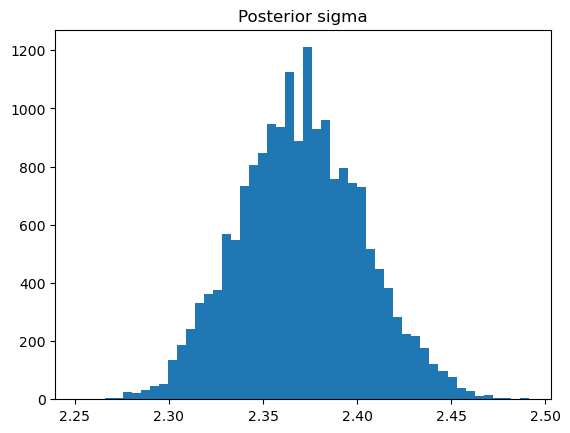

In [76]:
import matplotlib.pyplot as plt

mu_chain = res_lognorm["samples"][:, 0]
sigma_chain = res_lognorm["samples"][:, 1]

plt.plot(mu_chain)
plt.title("Lognorm MH trace: mu")
plt.show()

plt.plot(sigma_chain)
plt.title("Lognorm MH trace: sigma")
plt.show()

plt.hist(res_lognorm["posterior_samples"][:, 0], bins=50)
plt.title("Posterior mu")
plt.show()

plt.hist(res_lognorm["posterior_samples"][:, 1], bins=50)
plt.title("Posterior sigma")
plt.show()

# testing fit_movement_kernel with all step models and bayesian mcmc

In [188]:
import importlib
import movement_models.movement.movement_kernel as mk
importlib.reload(mk) 

<module 'movement_models.movement.movement_kernel' from '/Users/lubovkabo/Documents/TUM/MolZoologyLab/KONWIHR/HSA/movement_models/movement/movement_kernel.py'>

In [140]:
from movement_models.movement.movement_kernel import fit_movement_kernel_per_id

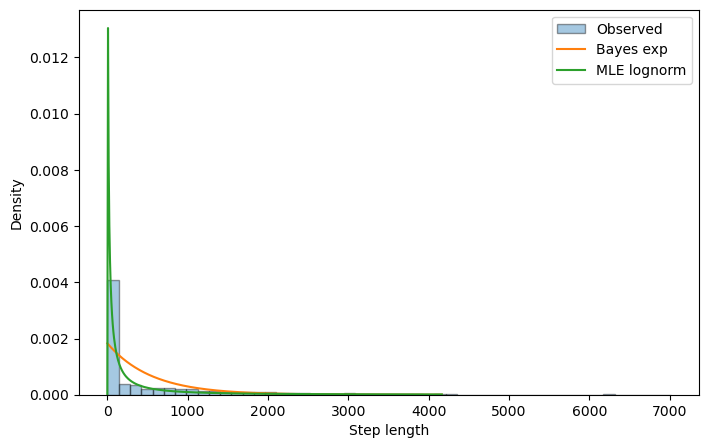

In [113]:
mle_lognorm_row = mle_res["model_table"].loc[
    mle_res["model_table"]["distribution"] == "lognorm"
].iloc[0]

s, scale = mle_lognorm_row["params"]

plt.figure(figsize=(8, 5))
plt.hist(x, bins=50, density=True, alpha=0.4, edgecolor="black", label="Observed")
plt.plot(xx, stats.expon.pdf(xx, loc=0, scale=bayes_scale), label="Bayes exp")
plt.plot(xx, stats.lognorm.pdf(xx, s=s, loc=0, scale=scale), label="MLE lognorm")
plt.legend()
plt.xlabel("Step length")
plt.ylabel("Density")
plt.show()

In [127]:
res_bayes = mk.fit_step_distribution(
    step_subset,
    method="bayes"
)

res_bayes["distribution"]
res_bayes["waic"]
res_bayes["model_table"]

,distribution,waic
0,lognorm_bayes,34195.098133
1,weibull_bayes,34358.829943
2,gamma_bayes,34503.637667
3,exp_bayes,37747.007747


In [144]:
out = mk.fit_movement_kernel_per_id(
    reloc,
    step_method="bayes",
    proposal_sd=0.05,
)
out["summary"].head()

,ID,n_steps,step_distribution,step_q25,step_median,step_mean,step_q75,step_max,n_angles,vonmises_kappa,mixture_kappa,mixture_w,step_acceptance_rate
0,NPL38,2584,lognorm_bayes,8.809685,63.692252,546.335874,760.120739,7014.598776,2252,0.135231,6.79407,0.103583,0.2589


# testing bayesian angle models

In [169]:
import movement_models.movement.movement_kernel as mk
importlib.reload(mk)

<module 'movement_models.movement.movement_kernel' from '/Users/lubovkabo/Documents/TUM/MolZoologyLab/KONWIHR/HSA/movement_models/movement/movement_kernel.py'>

In [153]:
res_vm_bayes = mk.fit_vonmises_distribution_bayes(
    angle_subset,
    proposal_sd=0.5,
)

res_vm_bayes

{'n': 2252,
 'distribution': 'vonmises_bayes',
 'posterior_mean_kappa': 0.12179688473976312,
 'posterior_median_kappa': 0.12278822054109272,
 'posterior_q025_kappa': 0.05480846414224228,
 'posterior_q975_kappa': 0.18311986593354412,
 'posterior_mean_mu': 0.09218277704623211,
 'posterior_median_mu': 0.0908010101259542,
 'posterior_q025_mu': -0.42199797641548464,
 'posterior_q975_mu': 0.5890596619432591,
 'posterior_mean_params': (0.12179688473976312, 0.09218277704623211),
 'posterior_median_params': (0.12278822054109272, 0.0908010101259542),
 'posterior_q025_params': (0.05480846414224228, -0.42199797641548464),
 'posterior_q975_params': (0.18311986593354412, 0.5890596619432591),
 'acceptance_rate': 0.2948,
 'init_params': (1.0, 0.0),
 'proposal_sd': 0.5,
 'prior_scale': 10.0,
 'samples': array([[0.67653596, 0.74825618],
        [0.2539145 , 0.41822428],
        [0.08825941, 0.66740418],
        ...,
        [0.12389946, 0.31950533],
        [0.12389946, 0.31950533],
        [0.12389946,

In [164]:
res_mix_bayes = mk.fit_vm_uniform_distribution_bayes(
    angle_subset,
    proposal_sd=0.3,
)

res_mix_bayes

{'n': 2252,
 'distribution': 'vm_uniform_bayes',
 'posterior_mean_kappa': 6.960472913027316,
 'posterior_median_kappa': 6.598902203683905,
 'posterior_q025_kappa': 4.008284355273496,
 'posterior_q975_kappa': 11.961894115955797,
 'posterior_mean_w': 0.10243148317126582,
 'posterior_median_w': 0.102089255581906,
 'posterior_q025_w': 0.07284426393659713,
 'posterior_q975_w': 0.13401358556866658,
 'posterior_mean_params': (6.960472913027316, 0.10243148317126582),
 'posterior_median_params': (6.598902203683905, 0.102089255581906),
 'posterior_q025_params': (4.008284355273496, 0.07284426393659713),
 'posterior_q975_params': (11.961894115955797, 0.13401358556866658),
 'acceptance_rate': 0.37525,
 'init_params': (1.0, 0.5),
 'proposal_sd': 0.3,
 'prior_scale': 10.0,
 'samples': array([[0.74121913, 0.40394747],
        [0.74121913, 0.40394747],
        [0.74121913, 0.40394747],
        ...,
        [7.26700456, 0.10068342],
        [7.61652328, 0.10644906],
        [7.61652328, 0.10644906]]),
 

# testing bayesian mcmc in general

In [194]:
out_angle_auto = mk.fit_movement_kernel_per_id(
    reloc,
    step_method="bayes",
    angle_method="bayes",
)

out_angle_auto["summary"].head()

,ID,n_steps,step_distribution,step_q25,step_median,step_mean,step_q75,step_max,n_angles,angle_distribution,...,angle_waic,angle_acceptance_rate,angle_posterior_mean_kappa,angle_posterior_median_kappa,angle_posterior_q025_kappa,angle_posterior_q975_kappa,angle_posterior_mean_w,angle_posterior_median_w,angle_posterior_q025_w,angle_posterior_q975_w
0,NPL38,2584,lognorm_bayes,8.809685,63.692252,546.335874,760.120739,7014.598776,2252,vm_uniform_bayes,...,8205.41288,0.36585,6.98262,6.655604,3.943071,11.767176,0.103012,0.102632,0.073988,0.134508


In [195]:
out_mix_bayes["summary"].filter(regex="angle").head()

,n_angles,angle_distribution,angle_acceptance_rate,angle_posterior_mean_kappa,angle_posterior_median_kappa,angle_posterior_q025_kappa,angle_posterior_q975_kappa,angle_posterior_mean_w,angle_posterior_median_w,angle_posterior_q025_w,angle_posterior_q975_w
0,2252,vm_uniform_bayes,0.36275,7.03265,6.712158,4.051155,11.713959,0.102719,0.102133,0.073935,0.134997


In [196]:
out_angle_auto["summary"][["step_distribution", "angle_distribution", "angle_waic"]].head()

,step_distribution,angle_distribution,angle_waic
0,lognorm_bayes,vm_uniform_bayes,8205.41288


In [191]:
res_angle_bayes = mk.fit_turn_angle_distribution(
    angle_subset,
    method="bayes",
    bayes_model=None,
    proposal_sd=0.1,
)

res_angle_bayes["distribution"]
res_angle_bayes["waic"]
res_angle_bayes["model_table"]

,distribution,waic
0,vm_uniform_bayes,8205.558193
1,vonmises_bayes,8261.625336
